<a href="https://colab.research.google.com/github/LojainAhmad25/cybersecurity-intrusion-detection/blob/main/Cybersecurity_Intrusion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
...

Ellipsis

In [3]:
path = kagglehub.dataset_download("dnkumars/cybersecurity-intrusion-detection-dataset")
print("Dataset folder path:", path)

Using Colab cache for faster access to the 'cybersecurity-intrusion-detection-dataset' dataset.
Dataset folder path: /kaggle/input/cybersecurity-intrusion-detection-dataset


In [4]:
data = pd.read_csv("/kaggle/input/cybersecurity-intrusion-detection-dataset/cybersecurity_intrusion_data.csv")
print(data.shape)
data.head()

(9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [5]:
print(data.shape)
data.head()

(9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [6]:
data.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [10]:
data.isnull().sum()
print((data.isnull().sum() / len(data) * 100).round(2))

session_id              0.00
network_packet_size     0.00
protocol_type           0.00
login_attempts          0.00
session_duration        0.00
encryption_used        20.61
ip_reputation_score     0.00
failed_logins           0.00
browser_type            0.00
unusual_time_access     0.00
attack_detected         0.00
dtype: float64


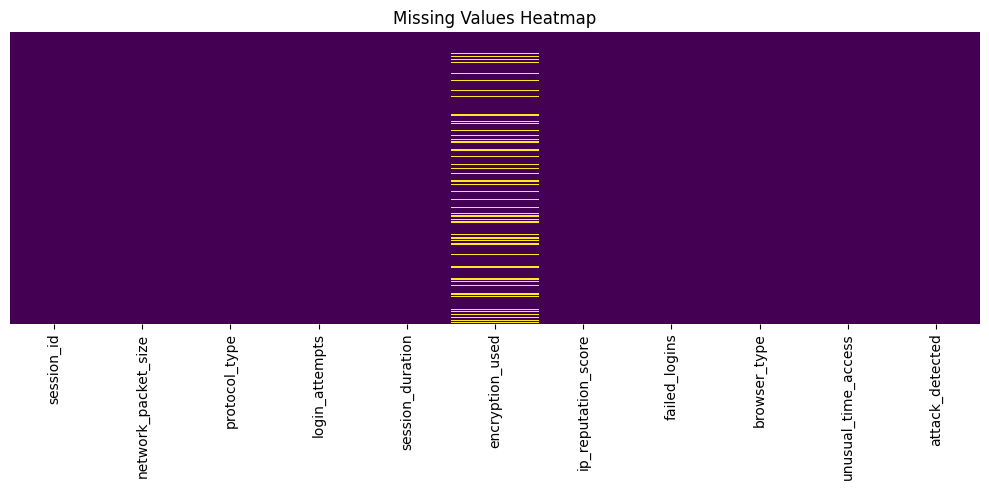

In [12]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

In [16]:
# Separate column types
num_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

# Remove target from imputation
target = 'attack_detected'
if target in num_cols:
    num_cols.remove(target)

# Fill numerical columns with MEDIAN (robust to outliers)
for col in num_cols:
    if data[col].isnull().sum() > 0:
        median_val = data[col].median()
        data[col].fillna(median_val, inplace=True)
        print(f"[NUM] '{col}' filled with median: {median_val}")

# Fill categorical columns with MODE
for col in cat_cols:
    if data[col].isnull().sum() > 0:
        mode_val = data[col].mode()[0]
        data[col].fillna(mode_val, inplace=True)
        print(f"[CAT] '{col}' filled with mode: {mode_val}")

In [18]:
print("\n--- After Handling ---")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")


--- After Handling ---
session_id             0
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64

Total missing values: 0


In [20]:
print(f"Duplicates: {data.duplicated().sum()}")


Duplicates: 0


In [24]:
data.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


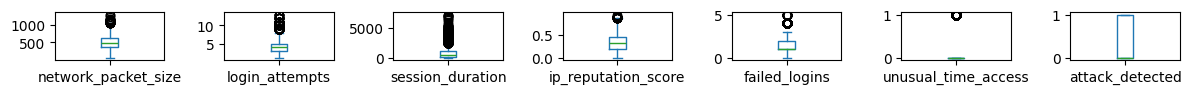

In [27]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

data[num_cols].plot(kind='box', figsize=(12, 6), subplots=True, layout=(7, 7))
plt.tight_layout()
plt.show()

In [31]:
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    print(f"{col:25} → {outliers} outliers")


network_packet_size       → 37 outliers
login_attempts            → 206 outliers
session_duration          → 418 outliers
ip_reputation_score       → 21 outliers
failed_logins             → 323 outliers
unusual_time_access       → 1430 outliers
attack_detected           → 0 outliers
